# Verification: Regional DSK model

This notebook recreates following climate shock scenarios of DSK model from Reissl et al (2025) on the regional version of the model.

|Scenario                    |flags                                             |
|----------------------------|--------------------------------------------------|
|Baseline (No shocks)        |flag_shockexperiment = 0;                         |
|Capital Stock Shocks (CS)   | flag_shockexperiment = 1; flag_capshocks = 1;    |
|Productivity Shocks (LS+EF) | flag_shockexperiment = 1; flag_prodshocks = 1;   |

In [1]:
from pathlib import Path
import sys

# Load reusable reader from scripts/read_batch_runs.py
project_root = Path.cwd()
if not (project_root / "scripts").exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [2]:
import importlib
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import plotly.graph_objects as go
import seaborn as sns


import plotly.graph_objects as go
from plotly.subplots import make_subplots

import scripts.read_batch_runs as _rbr
importlib.reload(_rbr)

from scripts.read_batch_runs import (
    load_simulation_results_matrix,
    check_regional_consistency,
)
from scripts.visualise_shocks import *

## Define PATH

In [3]:
# define paths to experiment runs.
PATHS = {
    'hrhs' : Path("/Users/anmolsoni/Nextcloud/projects/Regionalised-SFC-DSK/verifications/homogenos_regions_homogenous_shocks"),
    'dsk_sfc' : Path("/Users/anmolsoni/Nextcloud/projects/Regionalised-SFC-DSK/verifications/dsk_sfc")
    }

# load simulation result matrices
sim_matrix = {}
for PATH in PATHS.keys():
    sim_matrix[PATH] = load_simulation_results_matrix(PATHS[PATH])

Found 3 scenario candidate folders under /Users/anmolsoni/Nextcloud/projects/Regionalised-SFC-DSK/verifications/homogenos_regions_homogenous_shocks
Column count mismatch: data_cols=47, yaml_cols=53.
Column count mismatch: data_cols=25, yaml_cols=30.
Column count mismatch: data_cols=25, yaml_cols=30.
Column count mismatch: data_cols=25, yaml_cols=30.
Column count mismatch: data_cols=25, yaml_cols=30.
Column count mismatch: data_cols=47, yaml_cols=53.
Column count mismatch: data_cols=25, yaml_cols=30.
Column count mismatch: data_cols=25, yaml_cols=30.
Column count mismatch: data_cols=25, yaml_cols=30.
Column count mismatch: data_cols=25, yaml_cols=30.
Column count mismatch: data_cols=47, yaml_cols=53.
Column count mismatch: data_cols=25, yaml_cols=30.
Column count mismatch: data_cols=25, yaml_cols=30.
Column count mismatch: data_cols=25, yaml_cols=30.
Column count mismatch: data_cols=25, yaml_cols=30.
Column count mismatch: data_cols=47, yaml_cols=53.
Column count mismatch: data_cols=25,

In [4]:
# Extract simulation results
scenario_results = {}
for sim in sim_matrix.keys():
    for scenario_num in sim_matrix[sim].scenario.unique():
        scenario_results[f"{sim}_{scenario_num}"] = sim_matrix[sim].loc[sim_matrix[sim].scenario == scenario_num]
        

In [5]:
scenario_results.keys()

dict_keys(['hrhs_1', 'hrhs_2', 'hrhs_3', 'dsk_sfc_1'])

## Compare Shocks 

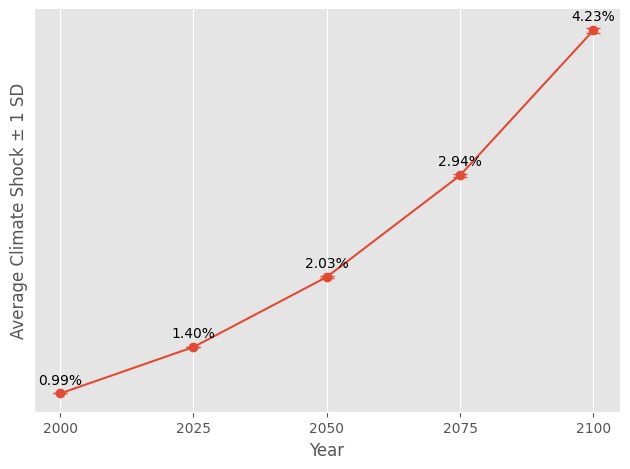

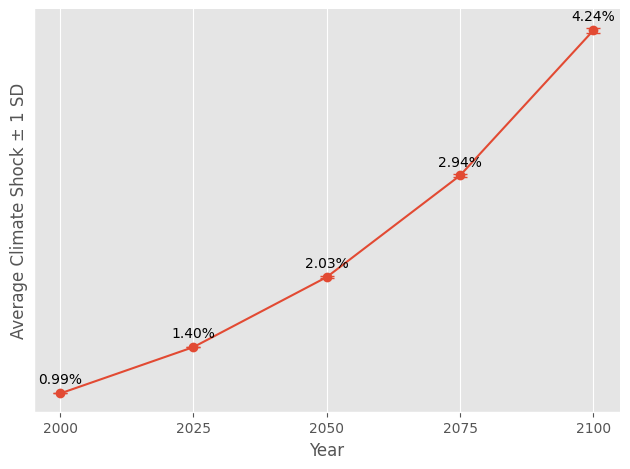

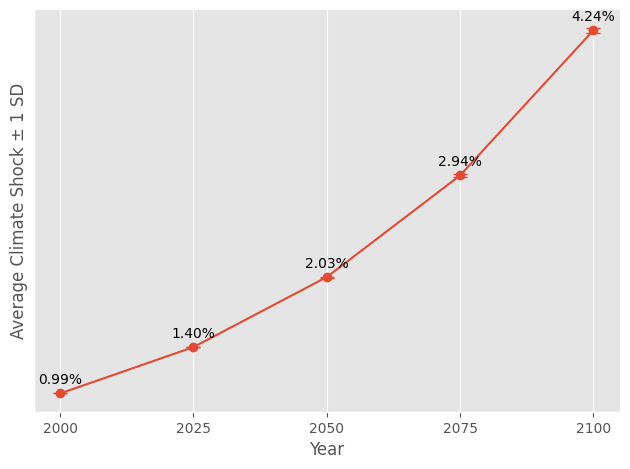

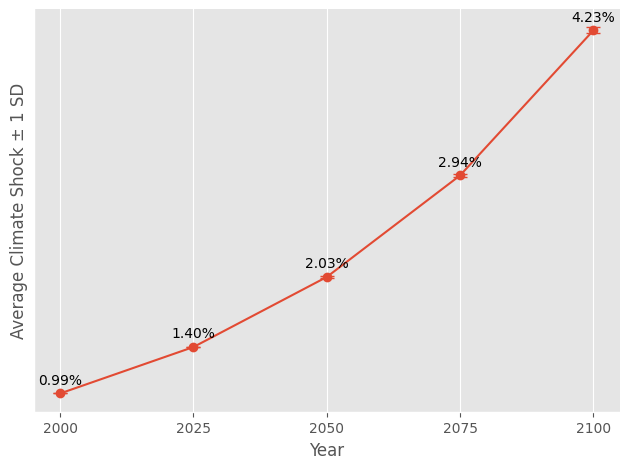

In [68]:
#  LP Shocks
for scenario in ['hrhs_2', 'dsk_sfc_2', 'hrhs_3', 'dsk_sfc_3']:
    get_shocks(scenario_results[scenario])

In [6]:
# Compute GDP_r growth
def compute_gdp_r_growth(df):
    """Compute annualized GDP growth per row for panel simulation output.

    Growth is computed within each (scenario, run, region) trajectory as:
        ((GDP_r_t / GDP_r_t-1) ** 4 - 1) * 100
    where 4 annualizes quarter-over-quarter growth.

    Parameters
    ----------
    df : pandas.DataFrame
        Input frame containing at least: scenario, run, region, t, and GDP_r.

    Returns
    -------
    pandas.Series
        Annualized growth in percent, aligned to ``df.index``. The first
        timestep in each group is NaN.

    Raises
    ------
    KeyError
        If required grouping columns or a GDP column are missing.
    """
    required_group_cols = ["scenario", "run", "region", "t"]
    missing_group_cols = [col for col in required_group_cols if col not in df.columns]
    if missing_group_cols:
        raise KeyError(f"Missing required columns: {missing_group_cols}")

    gdp_col = "GDP_r" if "GDP_r" in df.columns else None
    if gdp_col is None:
        raise KeyError("Missing GDP column. Expected one of: 'GDP_r'")

    ordered = df[required_group_cols + [gdp_col]].sort_values(required_group_cols)
    prev_gdp = ordered.groupby(["scenario", "run", "region"], sort=False)[gdp_col].shift(1)

    growth = ((ordered[gdp_col] / prev_gdp) ** 4 - 1) * 100
    valid = (prev_gdp > 0) & (ordered[gdp_col] > 0)
    growth = growth.where(valid, np.nan)

    return growth.reindex(df.index)



def compute_GDP_r_volatility(df):
    """Compute annualized real GDP volatility per row for panel simulation output.

    Volatility is the expanding standard deviation of annualized GDP growth
    within each (scenario, run, region) trajectory.

    Parameters
    ----------
    df : pandas.DataFrame
        Input frame containing at least: scenario, run, region, t, and GDP_r.

    Returns
    -------
    pandas.Series
        Expanding standard deviation of annualized GDP growth (percentage points),
        aligned to ``df.index``. The first timestep in each group is NaN.

    Raises
    ------
    KeyError
        If required grouping columns or a GDP column are missing.
    """
    required_group_cols = ["scenario", "run", "region", "t"]
    missing_group_cols = [col for col in required_group_cols if col not in df.columns]
    if missing_group_cols:
        raise KeyError(f"Missing required columns: {missing_group_cols}")

    gdp_col = "GDP_r" if "GDP_r" in df.columns else None
    if gdp_col is None:
        raise KeyError("Missing GDP column. Expected one of: 'GDP_r'")

    ordered = df[required_group_cols + [gdp_col]].sort_values(required_group_cols).copy()
    prev_gdp = ordered.groupby(["scenario", "run", "region"], sort=False)[gdp_col].shift(1)

    growth = ((ordered[gdp_col] / prev_gdp) ** 4 - 1) * 100
    valid = (prev_gdp > 0) & (ordered[gdp_col] > 0)
    ordered["_growth"] = growth.where(valid, np.nan)

    volatility = ordered.groupby(["scenario", "run", "region"], sort=False)["_growth"].transform(
        lambda s: s.expanding(min_periods=2).std()
    )

    return volatility.reindex(df.index)



def compute_crisis_indicator(df, threshold=-5.0):
    """Create a binary crisis indicator from annual GDP growth (%).

    A crisis is defined as GDP_r_growth < threshold. With GDP_r_growth in percent,
    Lamperti et al. (2018) threshold is -5.0.

    Returns a row-aligned Series (1 = crisis, 0 = no crisis, NaN if growth is NaN).
    """
    required_cols = ["GDP_r_growth"]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise KeyError(f"Missing required columns: {missing_cols}")

    growth = df["GDP_r_growth"]
    out = growth.astype(float).copy()
    out.loc[:] = np.where(growth.notna(), (growth < threshold).astype(int), np.nan)
    return out.rename("crisis")

def compute_crisis_likelihood(
    df,
    group_cols=("run",),
    t_min=None,
    t_max=None,
    crisis_col="crisis",
):
    """Compute crisis likelihood by groups and optional time window.

    Likelihood = sum(crisis) / number_of_non_null_crisis_observations
    where crisis is a binary column (0/1).

    Parameters
    ----------
    df : pandas.DataFrame
        Input data containing group columns, timestep ``t`` (if filtered), and crisis column.
    group_cols : tuple[str, ...], default ("run",)
        Grouping dimensions for likelihood calculation.
    t_min : int | None, default None
        If provided, include observations with t >= t_min.
    t_max : int | None, default None
        If provided, include observations with t <= t_max.
    crisis_col : str, default "crisis"
        Name of crisis indicator column (binary 0/1).

    Returns
    -------
    pandas.Series
        Crisis likelihood by ``group_cols`` as float values in [0, 1].
    """
    required_cols = list(group_cols) + [crisis_col]
    if t_min is not None or t_max is not None:
        required_cols.append("t")

    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise KeyError(f"Missing required columns: {missing_cols}")

    work = df.copy()

    # Optional timestep filtering
    if t_min is not None:
        work = work[work["t"] >= t_min]
    if t_max is not None:
        work = work[work["t"] <= t_max]

    # Use only non-null crisis observations
    valid_obs = work[crisis_col].notna()
    obs_count = work[valid_obs].groupby(list(group_cols), sort=False)[crisis_col].count()
    crisis_sum = work[valid_obs].groupby(list(group_cols), sort=False)[crisis_col].sum()

    return (crisis_sum / obs_count.replace(0, np.nan)).astype(float).rename("crisis_likelihood")



In [7]:
for scenario in scenario_results.keys():
    #  Compute unemployment
    scenario_results[scenario]['Unemployment'] = (1 - scenario_results[scenario].EmploymentRate) * 100
    # Compute GDP volatility
    scenario_results[scenario]['GDP_r_volatility'] = compute_GDP_r_volatility(scenario_results[scenario])
    #  Compute Output Growth Rate
    scenario_results[scenario]['GDP_r_growth'] = compute_gdp_r_growth(scenario_results[scenario])
    #  Compute Real GDP (log-n)
    scenario_results[scenario]['GDP_r_ln'] = np.log(scenario_results[scenario]['GDP_r'])


In [8]:

def compare_scenarios(df_a, df_b, metric, t_min=200, label_a="DSK", label_b="HRHS", alpha=0.05, region="macro"):
    """Compare a metric between two scenario DataFrames using Welch's t-test.

    Observations are first averaged per Monte Carlo run (over t > t_min),
    so each run contributes exactly one independent data point to the test.

    Parameters
    ----------
    df_a, df_b : pandas.DataFrame
        Scenario DataFrames containing columns ``t``, ``run``, and ``metric``.
    metric : str
        Column name to compare (e.g. 'Unemployment', 'GDP_r_growth').
    t_min : int, default 200
        Only include observations with t > t_min before averaging.
    label_a, label_b : str
        Display labels for each scenario in printed output.
    alpha : float, default 0.05
        Significance level for the test.
    """
    # Filter to macro region if multiple regions present
    if "region" in df_a.columns and df_a["region"].nunique() > 1:
        df_a = df_a[df_a["region"] == region]
    if "region" in df_b.columns and df_b["region"].nunique() > 1:
        df_b = df_b[df_b["region"] == region]

    # Aggregate to run-level means (one independent observation per run)
    a = (
        df_a.loc[df_a["t"] > t_min, ["run", metric]]
        .groupby("run")[metric].mean()
        .dropna()
    )
    b = (
        df_b.loc[df_b["t"] > t_min, ["run", metric]]
        .groupby("run")[metric].mean()
        .dropna()
    )

    print(f"Metric : {metric}  (t > {t_min},  aggregated to run-level means)")
    print(f"  {label_a:10s}  mean={a.mean():.4f}  std={a.std():.4f}  n_runs={len(a)}")
    print(f"  {label_b:10s}  mean={b.mean():.4f}  std={b.std():.4f}  n_runs={len(b)}")

    # Welch's t-test on run-level means
    t_stat, p_value = stats.ttest_ind(a, b, equal_var=True)
    print(f"\n  Welch's t-test  (H0: equal means across runs)")
    print(f"    t-statistic : {t_stat:.4f}")
    print(f"    p-value     : {p_value:.4e}")
    print(f"    Significant : {'Yes' if p_value < alpha else 'No'} (α = {alpha})")
    print()


def compare_crisis_likelihood(df_a, df_b, t_min=200, threshold=-5.0,
                               label_a="DSK", label_b="HRHS", alpha=0.05):
    """Compare per-run crisis likelihood between two scenario DataFrames.

    For each run, crisis likelihood = proportion of quarters (t > t_min)
    where GDP_r_growth < threshold. The resulting per-run likelihoods are
    then compared with Welch's t-test, giving one independent observation
    per Monte Carlo run.

    Parameters
    ----------
    df_a, df_b : pandas.DataFrame
        Scenario DataFrames containing columns ``t``, ``run``,
        and ``GDP_r_growth``.
    t_min : int, default 200
        Only include observations with t > t_min.
    threshold : float, default -5.0
        Crisis threshold in percent (Lamperti et al. 2018: -5.0).
    label_a, label_b : str
        Display labels for each scenario in printed output.
    alpha : float, default 0.05
        Significance level for the test.
    """
    def _run_level_likelihood(df):
        # Filter to macro region if multiple regions present
        if "region" in df.columns and df["region"].nunique() > 1:
            df = df[df["region"] == "macro"]

        work = df.loc[df["t"] > t_min, ["run", "GDP_r_growth"]].copy()
        valid = work["GDP_r_growth"].notna()

        # Binary crisis flag per row
        work["_crisis"] = np.where(valid, (work["GDP_r_growth"] < threshold).astype(int), np.nan)

        # Per-run likelihood = crisis quarters / valid quarters
        obs   = work[valid].groupby("run")["_crisis"].count()
        crises = work[valid].groupby("run")["_crisis"].sum()
        return (crises / obs.replace(0, np.nan)).astype(float).dropna()

    a = _run_level_likelihood(df_a)
    b = _run_level_likelihood(df_b)

    print(f"Crisis likelihood  (GDP_r_growth < {threshold}%,  t > {t_min})")
    print(f"  {label_a:10s}  mean={a.mean():.4f}  std={a.std():.4f}  n_runs={len(a)}")
    print(f"  {label_b:10s}  mean={b.mean():.4f}  std={b.std():.4f}  n_runs={len(b)}")

    t_stat, p_value = stats.ttest_ind(a, b, equal_var=True)
    print(f"\n  Welch's t-test  (H0: equal crisis likelihood across runs)")
    print(f"    t-statistic : {t_stat:.4f}")
    print(f"    p-value     : {p_value:.4e}")
    print(f"    Significant : {'Yes' if p_value < alpha else 'No'} (α = {alpha})")
    print()

In [12]:
compare_scenarios(scenario_results["dsk_sfc_1"], scenario_results["hrhs_1"], metric="Unemployment")
compare_scenarios(scenario_results["dsk_sfc_1"], scenario_results["hrhs_1"], metric="GDP_r_volatility")
compare_scenarios(scenario_results["dsk_sfc_1"], scenario_results["hrhs_1"], metric="GDP_r_growth")

Metric : Unemployment  (t > 200,  aggregated to run-level means)
  DSK         mean=4.7049  std=0.2257  n_runs=50
  HRHS        mean=4.7177  std=0.2560  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : -0.2653
    p-value     : 7.9132e-01
    Significant : No (α = 0.05)

Metric : GDP_r_volatility  (t > 200,  aggregated to run-level means)
  DSK         mean=8.2887  std=0.6299  n_runs=50
  HRHS        mean=8.1270  std=0.5855  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : 1.3296
    p-value     : 1.8674e-01
    Significant : No (α = 0.05)

Metric : GDP_r_growth  (t > 200,  aggregated to run-level means)
  DSK         mean=1.3113  std=0.0785  n_runs=50
  HRHS        mean=1.2869  std=0.0649  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : 1.6882
    p-value     : 9.4550e-02
    Significant : No (α = 0.05)



## Compare Macro-level variables

In [9]:
def build_macro_snapshot_metric_figure(
    scenarios,
    metric,
    metric_label = '',
    ylabel=None,
    snap_ts=None,
    crisis_thr=-5.0,
    title=None,
    line_type = 'lines+markers',
    ncol_legend=3,
    CI_type='band',
    ymin=None,
    ymax=None
):
    """Build a single-panel Plotly figure for one macro metric across scenarios.

    Parameters
    ----------
    scenarios : dict
        Mapping like:
        {
            "Scenario name": {"df": <pandas.DataFrame>, "color": "<color>"},
            ...
        }
    metric : str
        One of: "Unemployment", "GDP_r_growth", "GDP_r_volatility", "crisis".
    ylabel : str | None
        Y-axis label. If None, inferred from metric.
    snap_ts : list[int] | None
        Snapshot timesteps to plot. Defaults to [200, 300, 400, 500, 600].
    crisis_thr : float
        Threshold for crisis likelihood when metric == "crisis".
    title : str | None
        Figure title. If None, generated from metric.
    ncol_legend : int
        Number of columns in the bottom legend. Default is 3.
    CI_type : str
        How to display the ±1 SD uncertainty. Options:
        - 'band'      : filled semi-transparent band (default).
        - 'error_bar' : symmetric error bars matching the line colour and dash.

    Returns
    -------
    plotly.graph_objects.Figure
        Configured single-panel figure.
    """
    if snap_ts is None:
        snap_ts = [200, 300, 400, 500, 600]

    if ylabel is None:
        ylabel = metric_label

    if title is None:
        title = f"{ylabel}"

    def _macro(df):
        if "region" in df.columns and df["region"].nunique() > 1:
            return df[df["region"] == "macro"]
        return df

    def _snap_stats(df, metric_name):
        work = _macro(df)
        work = work[work["t"].isin(snap_ts)][["run", "t", metric_name]].dropna(subset=[metric_name])
        by_t = work.groupby(["t", "run"])[metric_name].mean().groupby("t")
        return by_t.mean(), by_t.std().fillna(0)

    def _crisis_snap_stats(df, threshold=crisis_thr):
        work = _macro(df)
        work = work[work["t"].isin(snap_ts)][["run", "t", "GDP_r_growth"]].dropna(subset=["GDP_r_growth"]).copy()
        work["_crisis"] = (work["GDP_r_growth"] < threshold).astype(float)
        by_t = work.groupby(["t", "run"])["_crisis"].mean().groupby("t")
        return by_t.mean(), by_t.std().fillna(0)

    fig = go.Figure()

    for scenario_name, spec in scenarios.items():
        df = spec["df"]
        color = spec["color"]
        dash = spec["dash"]

        if metric == "crisis":
            mean_ts, std_ts = _crisis_snap_stats(df)
        else:
            mean_ts, std_ts = _snap_stats(df, metric)

        t_vals = mean_ts.index.values
        m_vals = mean_ts.values
        s_vals = std_ts.reindex(mean_ts.index).fillna(0).values

        if CI_type == 'band':
            # Phantom trace: legend icon shows combined fill + line style
            fig.add_trace(
                go.Scatter(
                    x=[None], y=[None],
                    mode="lines",
                    fill="toself",
                    fillcolor=color,
                    opacity=0.4,
                    line=dict(color=color, width=1, dash=dash),
                    name=scenario_name,
                    legendgroup=scenario_name,
                    showlegend=False,
                    visible="legendonly",
                )
            )

            # SD band
            fig.add_trace(
                go.Scatter(
                    x=np.concatenate([t_vals, t_vals[::-1]]),
                    y=np.concatenate([m_vals + s_vals, (m_vals - s_vals)[::-1]]),
                    fill="toself",
                    fillcolor=color,
                    opacity=0.12,
                    line=dict(width=1),
                    name=scenario_name,
                    legendgroup=scenario_name,
                    showlegend=False,
                    visible=True,
                    hoverinfo="skip",
                )
            )

            # Mean line
            fig.add_trace(
                go.Scatter(
                    x=t_vals,
                    y=m_vals,
                    mode=line_type,
                    name=scenario_name,
                    line=dict(color=color, width=2, dash=dash),
                    marker=dict(color=color, size=8, symbol="circle",
                                line=dict(color=color, width=1)),
                    legendgroup=scenario_name,
                    showlegend=True,
                )
            )

        else:  # 'error_bar'
            # Mean line with symmetric ±1 SD error bars; single legend entry
            fig.add_trace(
                go.Scatter(
                    x=t_vals,
                    y=m_vals,
                    mode=line_type,
                    name=scenario_name,
                    line=dict(color=color, width=2, dash=dash),
                    marker=dict(color=color, size=8, symbol="circle",
                                line=dict(color=color, width=1)),
                    error_y=dict(
                        type="data",
                        array=s_vals,
                        visible=True,
                        color=color,
                        thickness=1.5,
                        width=4,
                    ),
                    legendgroup=scenario_name,
                    showlegend=True,
                )
            )

    fig.update_xaxes(range=[min(snap_ts), max(snap_ts)+10], title_text="Timestep (t)", tickvals=snap_ts)
    if ymin is None:
        fig.update_yaxes(title_text=ylabel)
    else:
        fig.update_yaxes(range=[ymin, ymax], title_text=ylabel)

    if min(snap_ts) <= 199 <= max(snap_ts):
        fig.add_vline(
            x=200,
            line_width=1.5,
            line_dash="dash",
            line_color="black",
            annotation_text="climate shocks start",
            annotation_position="top right",
        )

    ncol_legend += 1

    fig.update_layout(
        height=500,
        width=700,
        template="simple_white",
        margin=dict(l=0, r=10, t=30, b=10),
        paper_bgcolor='rgba(0,0,0,0)',
        plot_bgcolor='rgba(0,0,0,0)',
        legend=dict(
            orientation="h",
            entrywidth=(1 / ncol_legend)* 1.25,
            entrywidthmode="fraction",
            x=0.5,
            y=-0.2,
            xanchor="center",
            yanchor="top",
            tracegroupgap=4,
            # title_text="",
            
        ),
    )

    return fig


### Real GDP

In [73]:
SCENARIOS = {
    "Reg DSK: No Shock": {"df": scenario_results["hrhs_1"], "color": "#009933", 'dash': 'solid'},
    "Reg DSK: CS": {"df": scenario_results["hrhs_2"], "color": "#ff3300",'dash': 'solid'},
    "Reg DSK: LP + EF": {"df": scenario_results["hrhs_3"], "color": "#0052cc",'dash': 'solid'},
    "DSK: No Shock": {"df": scenario_results["dsk_sfc_1"], "color": "#00ff55", 'dash': 'dot'},
    "DSK: CS": {"df": scenario_results["dsk_sfc_2"], "color": "#ff9980", 'dash': 'dot'},
    "DSK: LP + EF": {"df": scenario_results["dsk_sfc_3"], "color": "#66a3ff", 'dash': 'dot'}
}
fig1 = build_macro_snapshot_metric_figure(
    scenarios=SCENARIOS,
    metric="GDP_r_ln",
    metric_label='ln',
    snap_ts=np.arange(200, 620, 20),
    title='Real GDP',
    line_type='lines',
    ncol_legend=3,
    CI_type='error_bar',
    ymin=12.8, ymax=14
)

fig1.write_image("../figures/verification/GDP_r_ln.pdf", width=750, height=500, scale=2)
fig1.write_html("../figures/verification/GDP_r_ln.html", include_plotlyjs="cdn")

In [74]:
compare_scenarios(scenario_results["dsk_sfc_1"], scenario_results["hrhs_1"], metric="GDP_r")
compare_scenarios(scenario_results["dsk_sfc_2"], scenario_results["hrhs_2"], metric="GDP_r")
compare_scenarios(scenario_results["dsk_sfc_3"], scenario_results["hrhs_3"], metric="GDP_r")


Metric : GDP_r  (t > 200,  aggregated to run-level means)
  DSK         mean=698341.9075  std=26331.9787  n_runs=50
  HRHS        mean=693744.3658  std=23778.6744  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : 0.9163
    p-value     : 3.6176e-01
    Significant : No (α = 0.05)

Metric : GDP_r  (t > 200,  aggregated to run-level means)
  DSK         mean=699654.1376  std=28430.1434  n_runs=50
  HRHS        mean=697735.7103  std=21576.5058  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : 0.3801
    p-value     : 7.0471e-01
    Significant : No (α = 0.05)

Metric : GDP_r  (t > 200,  aggregated to run-level means)
  DSK         mean=625071.3462  std=22868.6323  n_runs=50
  HRHS        mean=632431.3550  std=23018.2136  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : -1.6039
    p-value     : 1.1195e-01
    Significant : No (α = 0.05)



#### Std. dev. of filtered Real GDP

In [75]:
def plot_gdp_r_std_notched_box(
    metric,
    scenario_names,
    labels=None,
    title="Standard deviation of filtered real GDP",
    colors=None,
    y_label="Std. Dev. of GDP_r",
    figsize=(6, 5.5),
    dpi=140,
    save_path=None,
):
    """Plot given metric as a notched Matplotlib box plot.

    Parameters
    ----------
    metric : dict
        Mapping scenario name -> pandas Series/array of metric values.
    scenario_names : list[str]
        Scenarios to plot in this order.
    labels : list[str] | None
        Display labels for x-axis. If None, scenario_names are used.
    title : str
        Figure title.
    colors : list[str] | dict[str, str] | None
        Box outline/median colors. If dict, keyed by scenario name.
    y_label : str
        Y-axis label.
    figsize : tuple[float, float]
        Figure size in inches.
    dpi : int
        Figure resolution.
    save_path : str | None
        Optional path to save the figure.
    """
    if labels is None:
        labels = scenario_names

    if len(labels) != len(scenario_names):
        raise ValueError("labels length must match scenario_names length")

    missing = [name for name in scenario_names if name not in metric]
    if missing:
        raise KeyError(f"Missing scenarios in gdp_r_std: {missing}")

    if colors is None:
        palette = ["#0B9E77", "#E41A1C", "#56B4E9"]
        color_list = [palette[i % len(palette)] for i in range(len(scenario_names))]
    elif isinstance(colors, dict):
        color_list = [colors[name] for name in scenario_names]
    else:
        if len(colors) != len(scenario_names):
            raise ValueError("colors length must match scenario_names length")
        color_list = list(colors)

    data = []
    for name in scenario_names:
        values = metric[name]
        if hasattr(values, "dropna"):
            values = values.dropna()
        data.append(np.asarray(values, dtype=float))

    plt.style.use("ggplot")
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    bp = ax.boxplot(
        data,
        tick_labels=labels,
        notch=True,
        patch_artist=True,
        widths=0.75,
        showfliers=True,
        whis=1.5,
    )

    for i, box in enumerate(bp["boxes"]):
        box.set(facecolor="none", edgecolor=color_list[i], linewidth=1.5)

    for i, whisker in enumerate(bp["whiskers"]):
        whisker.set(color=color_list[i // 2], linewidth=1.3)

    for i, cap in enumerate(bp["caps"]):
        cap.set(color=color_list[i // 2], linewidth=1.3)

    for i, median in enumerate(bp["medians"]):
        median.set(color=color_list[i], linewidth=2.4)

    for i, flier in enumerate(bp["fliers"]):
        flier.set(
            marker="o",
            markersize=5,
            markerfacecolor=color_list[i],
            markeredgecolor=color_list[i],
            alpha=1.0,
        )

    ax.set_title(title)
    ax.set_ylabel(y_label)
    ax.set_facecolor("#ffffff")
    ax.grid(True, axis="both", alpha=0.36, color='gray', linestyle='--', linewidth=0.5, which='both')

    if save_path:
        fig.savefig(save_path, bbox_inches="tight")

    plt.show()

In [76]:
GDP_r_std = {}
for scenario in scenario_results.keys():
    temp_df = scenario_results[scenario][scenario_results[scenario]['region']=='macro'].copy()
    temp_df = temp_df[temp_df['t']>200].copy()
    GDP_r_std[scenario] = temp_df.groupby(['run'])['GDP_r'].std() / temp_df.groupby(['run'])['GDP_r'].mean()

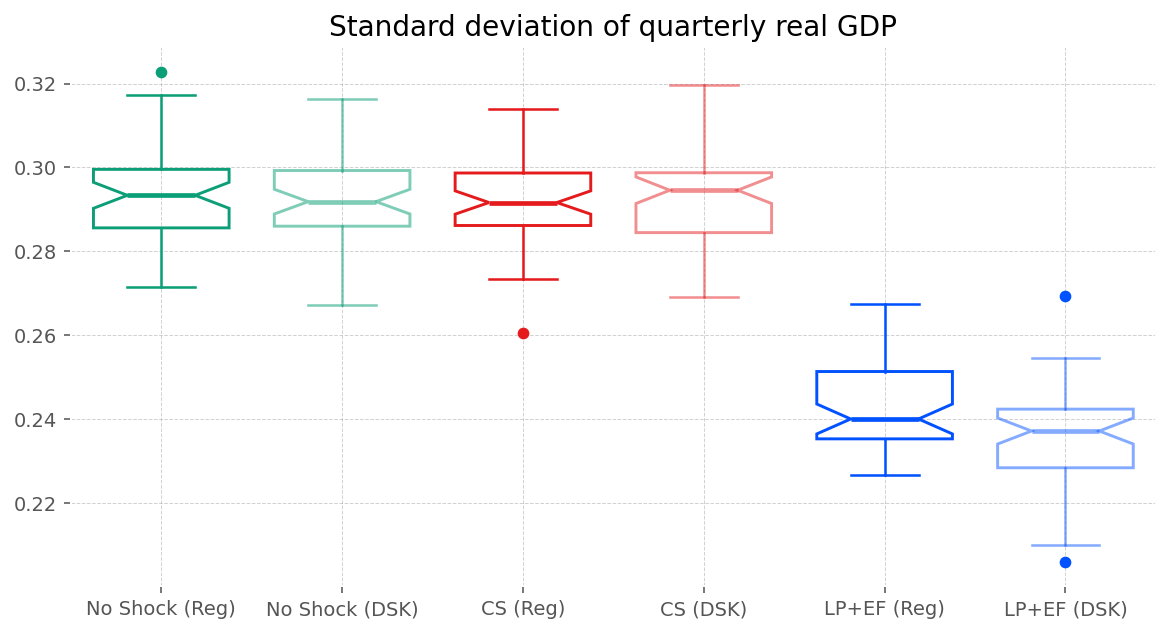

In [77]:
plot_gdp_r_std_notched_box(
    metric=GDP_r_std,
    scenario_names=["hrhs_1", "dsk_sfc_1", "hrhs_2","dsk_sfc_2", "hrhs_3","dsk_sfc_3"],
    labels=["No Shock (Reg)", "No Shock (DSK)", "CS (Reg)","CS (DSK)" , "LP+EF (Reg)", "LP+EF (DSK)"],
    colors=["#0B9E77","#0B9E7786", "#E41A1C","#E41A1D7E", "#0051FF","#0051FF7B"],
    figsize=(10, 5),
    title="Standard deviation of quarterly real GDP",
    y_label='',
    save_path="../figures/verification/GDP_r_stddev.pdf",
)

#### Avg. Annualized Real GDP Growth

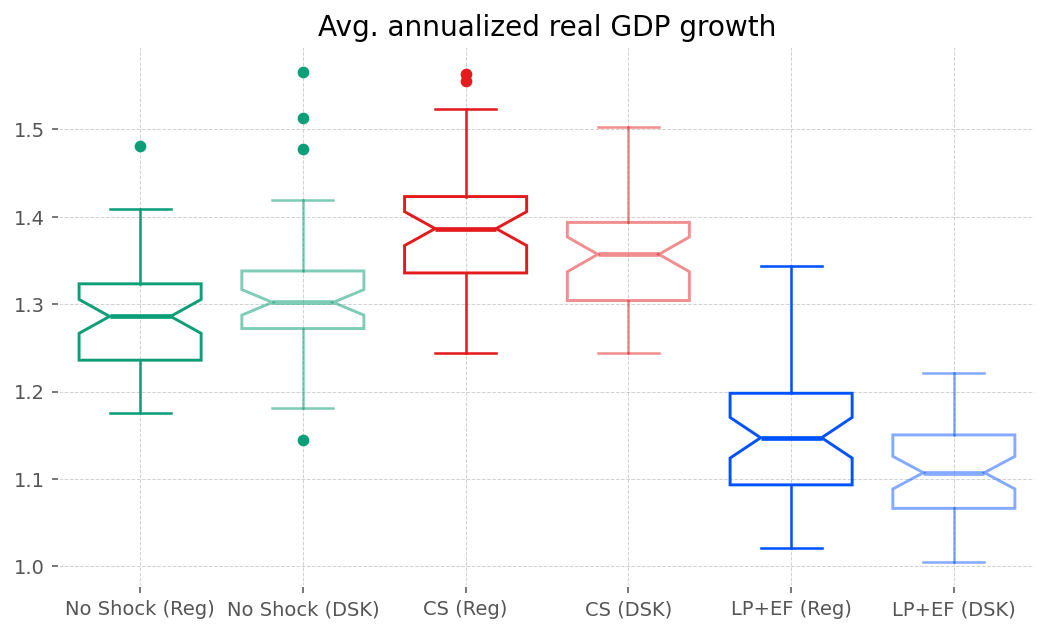

In [78]:
GDP_r_annualized_growth = {}
for scenario in scenario_results.keys():
    temp_df = scenario_results[scenario][scenario_results[scenario]['region']=='macro'].copy()
    temp_df = temp_df[temp_df['t']>200].copy()
    GDP_r_annualized_growth[scenario] = temp_df.groupby(['run'])['GDP_r_growth'].mean()


plot_gdp_r_std_notched_box(
    metric=GDP_r_annualized_growth,
    scenario_names=["hrhs_1", "dsk_sfc_1", "hrhs_2","dsk_sfc_2", "hrhs_3","dsk_sfc_3"],
    labels=["No Shock (Reg)", "No Shock (DSK)", "CS (Reg)","CS (DSK)" , "LP+EF (Reg)", "LP+EF (DSK)"],
    colors=["#0B9E77","#0B9E7786", "#E41A1C","#E41A1D7E", "#0051FF","#0051FF7B"],
    figsize=(9, 5),
    title="Avg. annualized real GDP growth",
    y_label='',
    save_path="../figures/verification/GDP_r_annualized_growth.pdf",
)

In [79]:
compare_scenarios(scenario_results["dsk_sfc_1"], scenario_results["hrhs_1"], metric="GDP_r_ln")
compare_scenarios(scenario_results["dsk_sfc_2"], scenario_results["hrhs_2"], metric="GDP_r_ln")
compare_scenarios(scenario_results["dsk_sfc_3"], scenario_results["hrhs_3"], metric="GDP_r_ln")


Metric : GDP_r_ln  (t > 200,  aggregated to run-level means)
  DSK         mean=13.4123  std=0.0363  n_runs=50
  HRHS        mean=13.4057  std=0.0327  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : 0.9463
    p-value     : 3.4632e-01
    Significant : No (α = 0.05)

Metric : GDP_r_ln  (t > 200,  aggregated to run-level means)
  DSK         mean=13.4141  std=0.0392  n_runs=50
  HRHS        mean=13.4119  std=0.0295  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : 0.3257
    p-value     : 7.4534e-01
    Significant : No (α = 0.05)

Metric : GDP_r_ln  (t > 200,  aggregated to run-level means)
  DSK         mean=13.3170  std=0.0354  n_runs=50
  HRHS        mean=13.3268  std=0.0348  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : -1.4043
    p-value     : 1.6338e-01
    Significant : No (α = 0.05)



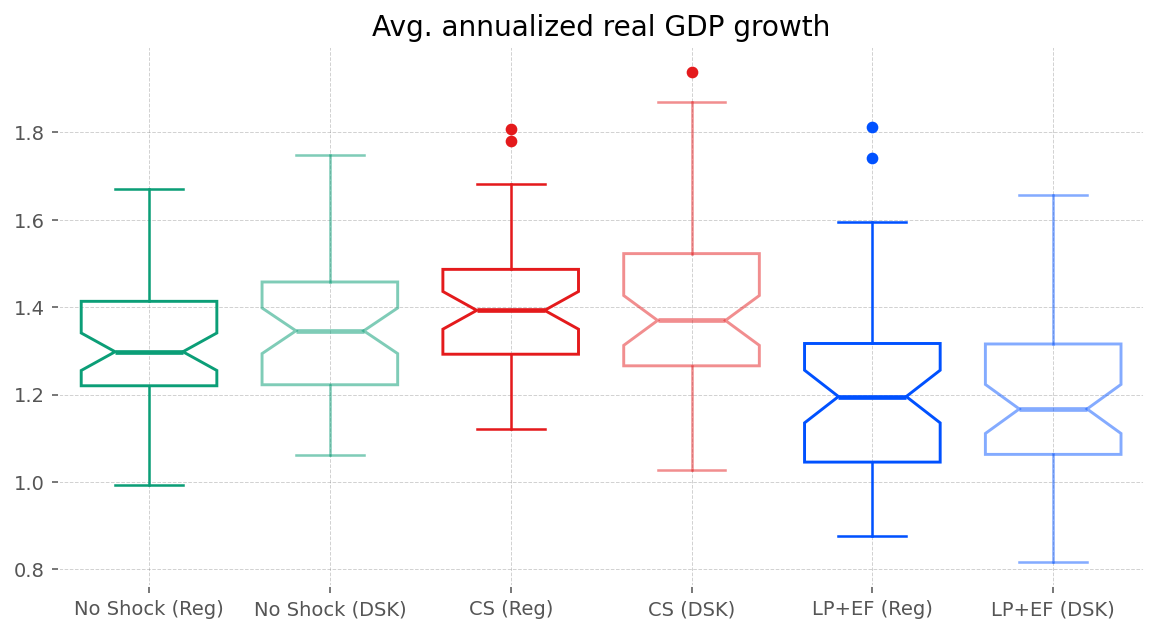

In [80]:
GDP_r_annualized_growth = {}
for scenario in scenario_results.keys():
    temp_df = scenario_results[scenario][scenario_results[scenario]['region']=='macro'].copy()
    temp_df = temp_df[temp_df['t'].between(200, 300, inclusive='neither')].copy()
    GDP_r_annualized_growth[scenario] = temp_df.groupby(['run'])['GDP_r_growth'].mean()

plot_gdp_r_std_notched_box(
    metric=GDP_r_annualized_growth,
    scenario_names=["hrhs_1", "dsk_sfc_1", "hrhs_2","dsk_sfc_2", "hrhs_3","dsk_sfc_3"],
    labels=["No Shock (Reg)", "No Shock (DSK)", "CS (Reg)","CS (DSK)" , "LP+EF (Reg)", "LP+EF (DSK)"],
    colors=["#0B9E77","#0B9E7786", "#E41A1C","#E41A1D7E", "#0051FF","#0051FF7B"],
    figsize=(10, 5),
    title="Avg. annualized real GDP growth",
    y_label='',
    save_path="../figures/verification/GDP_r_annualized_growth_200-300.pdf",
)

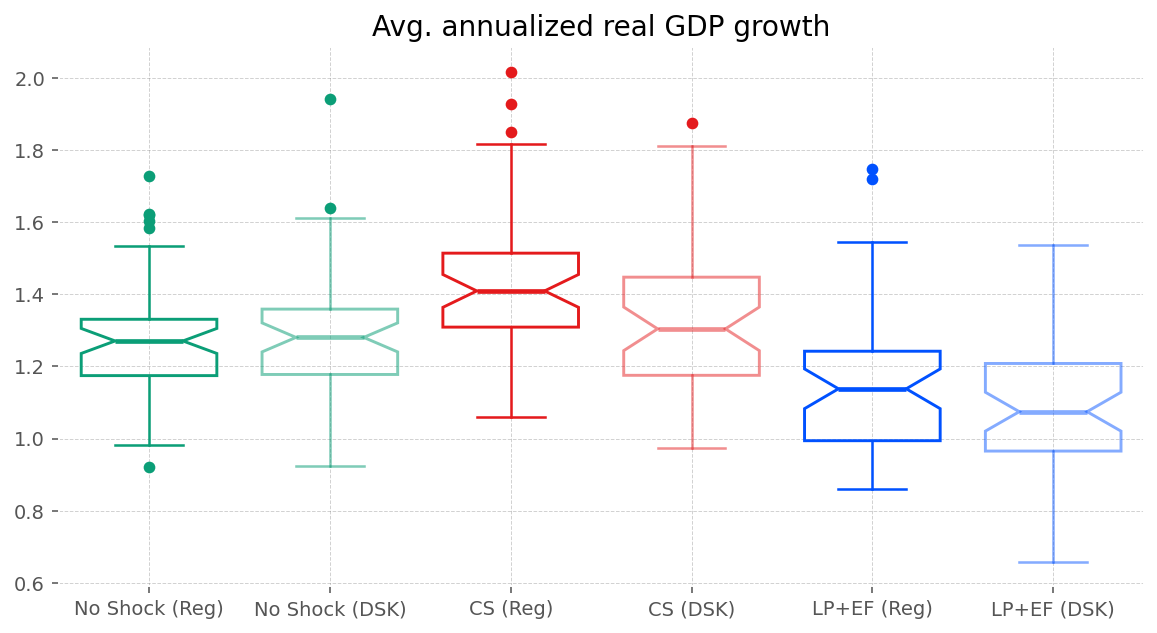

In [81]:
GDP_r_annualized_growth = {}
for scenario in scenario_results.keys():
    temp_df = scenario_results[scenario][scenario_results[scenario]['region']=='macro'].copy()
    temp_df = temp_df[temp_df['t'].between(300, 400, inclusive='neither')].copy()
    GDP_r_annualized_growth[scenario] = temp_df.groupby(['run'])['GDP_r_growth'].mean()

plot_gdp_r_std_notched_box(
    metric=GDP_r_annualized_growth,
    scenario_names=["hrhs_1", "dsk_sfc_1", "hrhs_2","dsk_sfc_2", "hrhs_3","dsk_sfc_3"],
    labels=["No Shock (Reg)", "No Shock (DSK)", "CS (Reg)","CS (DSK)" , "LP+EF (Reg)", "LP+EF (DSK)"],
    colors=["#0B9E77","#0B9E7786", "#E41A1C","#E41A1D7E", "#0051FF","#0051FF7B"],
    figsize=(10, 5),
    title="Avg. annualized real GDP growth",
    y_label='',
    save_path="../figures/verification/GDP_r_annualized_growth_300-400.pdf",
)

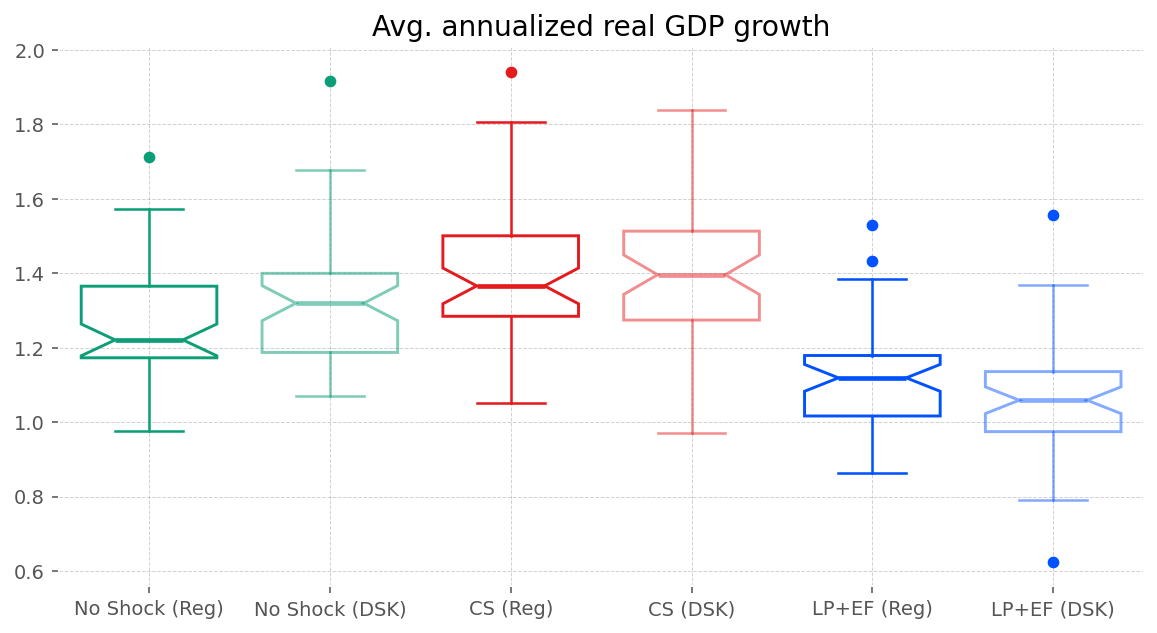

In [82]:
GDP_r_annualized_growth = {}
for scenario in scenario_results.keys():
    temp_df = scenario_results[scenario][scenario_results[scenario]['region']=='macro'].copy()
    temp_df = temp_df[temp_df['t'].between(400, 500, inclusive='neither')].copy()
    GDP_r_annualized_growth[scenario] = temp_df.groupby(['run'])['GDP_r_growth'].mean()

plot_gdp_r_std_notched_box(
    metric=GDP_r_annualized_growth,
    scenario_names=["hrhs_1", "dsk_sfc_1", "hrhs_2","dsk_sfc_2", "hrhs_3","dsk_sfc_3"],
    labels=["No Shock (Reg)", "No Shock (DSK)", "CS (Reg)","CS (DSK)" , "LP+EF (Reg)", "LP+EF (DSK)"],
    colors=["#0B9E77","#0B9E7786", "#E41A1C","#E41A1D7E", "#0051FF","#0051FF7B"],
    figsize=(10, 5),
    title="Avg. annualized real GDP growth",
    y_label='',
    save_path="../figures/verification/GDP_r_annualized_growth_400-500.pdf",
)

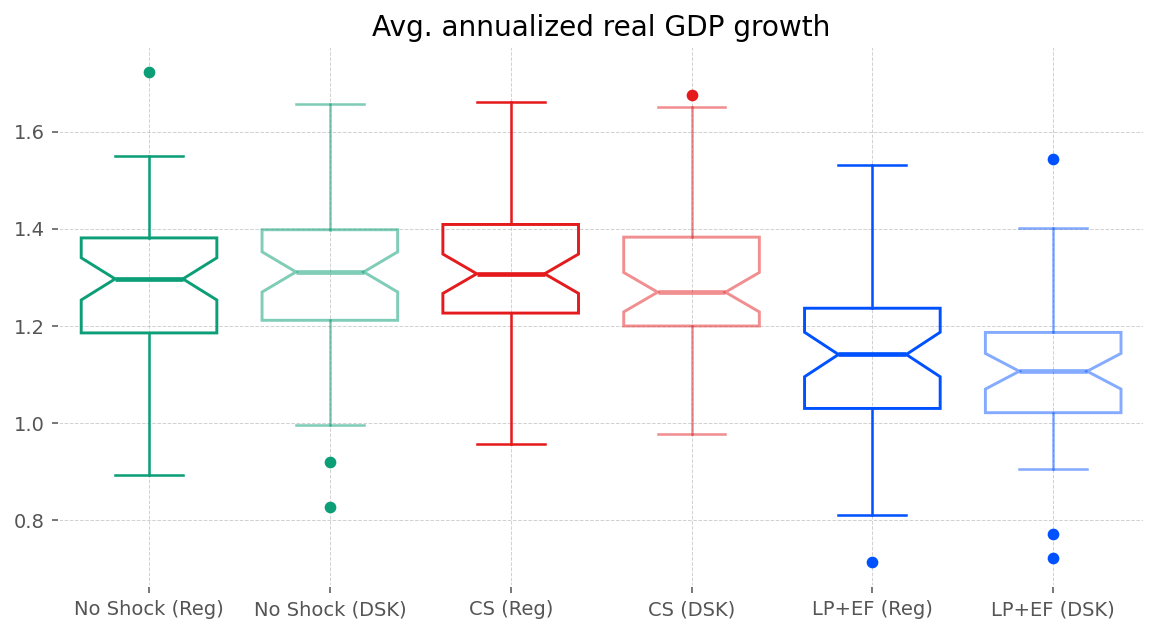

In [83]:
GDP_r_annualized_growth = {}
for scenario in scenario_results.keys():
    temp_df = scenario_results[scenario][scenario_results[scenario]['region']=='macro'].copy()
    temp_df = temp_df[temp_df['t'].between(500, 600, inclusive='neither')].copy()
    GDP_r_annualized_growth[scenario] = temp_df.groupby(['run'])['GDP_r_growth'].mean()

plot_gdp_r_std_notched_box(
    metric=GDP_r_annualized_growth,
    scenario_names=["hrhs_1", "dsk_sfc_1", "hrhs_2","dsk_sfc_2", "hrhs_3","dsk_sfc_3"],
    labels=["No Shock (Reg)", "No Shock (DSK)", "CS (Reg)","CS (DSK)" , "LP+EF (Reg)", "LP+EF (DSK)"],
    colors=["#0B9E77","#0B9E7786", "#E41A1C","#E41A1D7E", "#0051FF","#0051FF7B"],
    figsize=(10, 5),
    title="Avg. annualized real GDP growth",
    y_label='',
    save_path="../figures/verification/GDP_r_annualized_growth_500-600.pdf",
)

### Bad debt as % of nominal GDP

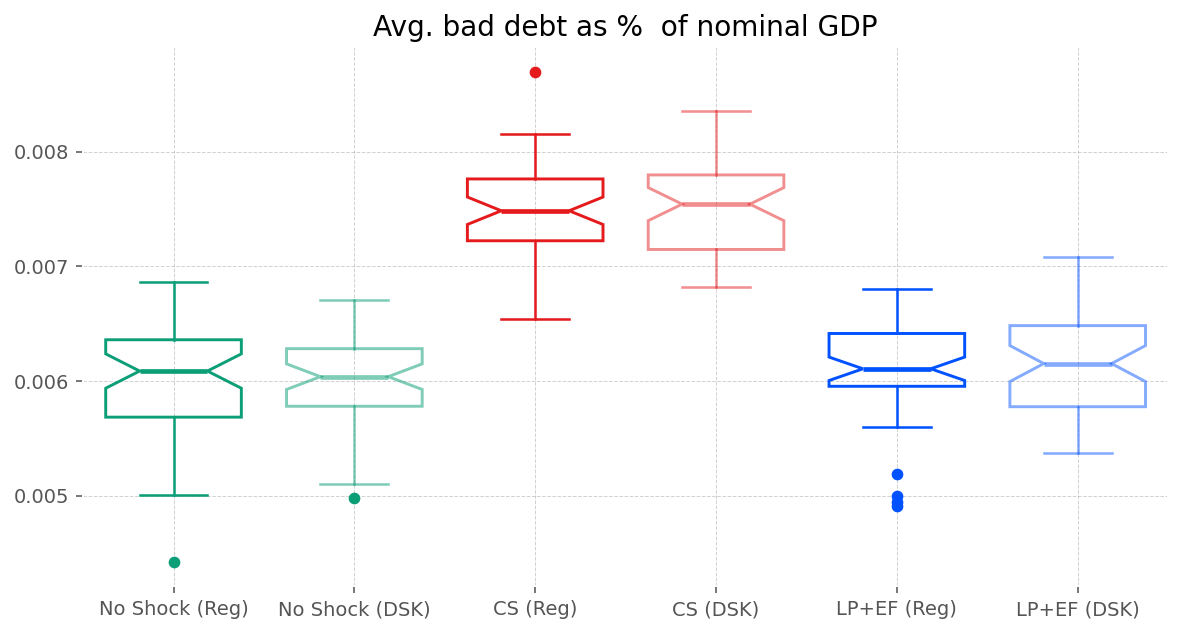

In [84]:
bad_debt_b_over_GDPn = {}
for scenario in scenario_results.keys():
    temp_df = scenario_results[scenario][scenario_results[scenario]['region']=='macro'].copy()
    temp_df = temp_df[temp_df['t']>200].copy()
    bad_debt_b_over_GDPn[scenario] = temp_df.groupby(['run'])['baddebt_b_over_GDP'].mean()
        

plot_gdp_r_std_notched_box(
    metric=bad_debt_b_over_GDPn,
    scenario_names=["hrhs_1", "dsk_sfc_1", "hrhs_2","dsk_sfc_2", "hrhs_3","dsk_sfc_3"],
    labels=["No Shock (Reg)", "No Shock (DSK)", "CS (Reg)","CS (DSK)" , "LP+EF (Reg)", "LP+EF (DSK)"],
    colors=["#0B9E77","#0B9E7786", "#E41A1C","#E41A1D7E", "#0051FF","#0051FF7B"],
    figsize=(10, 5),
    title="Avg. bad debt as %  of nominal GDP",
    y_label='',
    save_path="../figures/verification/baddebt_b_over_GDP.pdf",
)

In [85]:
SCENARIOS = {
    "Reg DSK: No Shock": {"df": scenario_results["hrhs_1"], "color": "#009933", 'dash': 'solid'},
    "Reg DSK: CS": {"df": scenario_results["hrhs_2"], "color": "#ff3300",'dash': 'solid'},
    "Reg DSK: LP + EF": {"df": scenario_results["hrhs_3"], "color": "#0052cc",'dash': 'solid'},
    "DSK: No Shock": {"df": scenario_results["dsk_sfc_1"], "color": "#00ff55", 'dash': 'dot'},
    "DSK: CS": {"df": scenario_results["dsk_sfc_2"], "color": "#ff9980", 'dash': 'dot'},
    "DSK: LP + EF": {"df": scenario_results["dsk_sfc_3"], "color": "#66a3ff", 'dash': 'dot'}
}
fig1 = build_macro_snapshot_metric_figure(
    scenarios=SCENARIOS,
    metric="baddebt_b_over_GDP",
    metric_label='',
    snap_ts=np.arange(200, 620, 20),
    title='baddebt_b_over_GDP',
    line_type='lines',
    ncol_legend=3,
    ymin=0,
    ymax=0.02,
    CI_type='error_bar',
)

# fig1.write_image("../figures/verification/baddebt_b_over_GDP.pdf", width=750, height=500, scale=2)
# fig1.write_html("../figures/verification/baddebt_b_over_GDP.html", include_plotlyjs="cdn")

In [86]:
compare_scenarios(scenario_results["dsk_sfc_1"], scenario_results["hrhs_1"], metric="baddebt_b_over_GDP")
compare_scenarios(scenario_results["dsk_sfc_2"], scenario_results["hrhs_2"], metric="baddebt_b_over_GDP")
compare_scenarios(scenario_results["dsk_sfc_3"], scenario_results["hrhs_3"], metric="baddebt_b_over_GDP")

Metric : baddebt_b_over_GDP  (t > 200,  aggregated to run-level means)
  DSK         mean=0.0060  std=0.0003  n_runs=50
  HRHS        mean=0.0060  std=0.0005  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : 0.1957
    p-value     : 8.4522e-01
    Significant : No (α = 0.05)

Metric : baddebt_b_over_GDP  (t > 200,  aggregated to run-level means)
  DSK         mean=0.0075  std=0.0004  n_runs=50
  HRHS        mean=0.0075  std=0.0004  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : 0.4017
    p-value     : 6.8881e-01
    Significant : No (α = 0.05)

Metric : baddebt_b_over_GDP  (t > 200,  aggregated to run-level means)
  DSK         mean=0.0061  std=0.0004  n_runs=50
  HRHS        mean=0.0061  std=0.0004  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : 0.5546
    p-value     : 5.8045e-01
    Significant : No (α = 0.05)



### Number of C-Firms failure

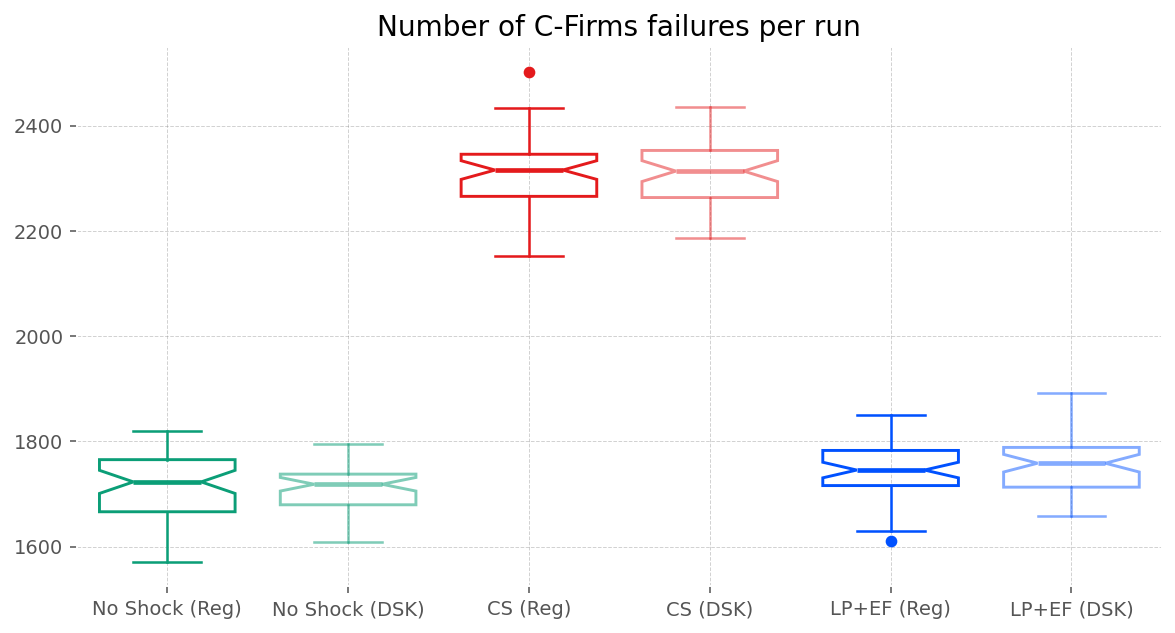

In [87]:
Exiting_CFirms = {}
for scenario in scenario_results.keys():
    temp_df = scenario_results[scenario][scenario_results[scenario]['region']=='macro'].copy()
    temp_df = temp_df[temp_df['t']>200].copy()
    Exiting_CFirms[scenario] = temp_df.groupby(['run'])['Exiting_C-Firms'].sum()
        

plot_gdp_r_std_notched_box(
    metric=Exiting_CFirms,
    scenario_names=["hrhs_1", "dsk_sfc_1", "hrhs_2","dsk_sfc_2", "hrhs_3","dsk_sfc_3"],
    labels=["No Shock (Reg)", "No Shock (DSK)", "CS (Reg)","CS (DSK)" , "LP+EF (Reg)", "LP+EF (DSK)"],
    colors=["#0B9E77","#0B9E7786", "#E41A1C","#E41A1D7E", "#0051FF","#0051FF7B"],
    figsize=(10, 5),
    title="Number of C-Firms failures per run",
    y_label='',
    save_path="../figures/verification/Exiting_C-Firms.pdf",
)

In [88]:
SCENARIOS = {
    "Reg DSK: No Shock": {"df": scenario_results["hrhs_1"], "color": "#009933", 'dash': 'solid'},
    "Reg DSK: CS": {"df": scenario_results["hrhs_2"], "color": "#ff3300",'dash': 'solid'},
    "Reg DSK: LP + EF": {"df": scenario_results["hrhs_3"], "color": "#0052cc",'dash': 'solid'},
    "DSK: No Shock": {"df": scenario_results["dsk_sfc_1"], "color": "#00ff55", 'dash': 'dot'},
    "DSK: CS": {"df": scenario_results["dsk_sfc_2"], "color": "#ff9980", 'dash': 'dot'},
    "DSK: LP + EF": {"df": scenario_results["dsk_sfc_3"], "color": "#66a3ff", 'dash': 'dot'}
}
fig1 = build_macro_snapshot_metric_figure(
    scenarios=SCENARIOS,
    metric='Exiting_C-Firms',
    metric_label='',
    snap_ts=np.arange(200, 620, 20),
    title='Exiting_C-Firms',
    line_type='lines',
    ncol_legend=3,
    ymin=0,
    ymax=12,
    CI_type='error_bar',
)

fig1.write_image("../figures/verification/Exiting_C-Firms.pdf", width=1200, height=800, scale=2)
fig1.write_html("../figures/verification/Exiting_C-Firms.html", include_plotlyjs="cdn")


In [89]:
fig1

In [90]:
compare_scenarios(scenario_results["dsk_sfc_1"], scenario_results["hrhs_1"], metric="Exiting_C-Firms")
compare_scenarios(scenario_results["dsk_sfc_2"], scenario_results["hrhs_2"], metric="Exiting_C-Firms")
compare_scenarios(scenario_results["dsk_sfc_3"], scenario_results["hrhs_3"], metric="Exiting_C-Firms")

Metric : Exiting_C-Firms  (t > 200,  aggregated to run-level means)
  DSK         mean=4.2832  std=0.1031  n_runs=50
  HRHS        mean=4.2936  std=0.1539  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : -0.3971
    p-value     : 6.9217e-01
    Significant : No (α = 0.05)

Metric : Exiting_C-Firms  (t > 200,  aggregated to run-level means)
  DSK         mean=5.7762  std=0.1548  n_runs=50
  HRHS        mean=5.7675  std=0.1637  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : 0.2730
    p-value     : 7.8541e-01
    Significant : No (α = 0.05)

Metric : Exiting_C-Firms  (t > 200,  aggregated to run-level means)
  DSK         mean=4.3864  std=0.1358  n_runs=50
  HRHS        mean=4.3662  std=0.1289  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : 0.7629
    p-value     : 4.4734e-01
    Significant : No (α = 0.05)



### Sectoral net worth as % of nominal GDP

In [91]:
BG_COLOR = "white"  # use "rgba(0,0,0,0)" for transparent
GRID_COLOR = "rgba(128, 128, 128, 0.5)"

mean_sectoral_net_worth = {}
sectoral_net_worth = {}
sector_order = ["K-Firms", "C-Firms", "Households", "Banks", "Energy", "Govt."]

for scenario in ["dsk_sfc_1", "hrhs_1", "dsk_sfc_2", "hrhs_2", "dsk_sfc_3", "hrhs_3"]:
    temp_df = scenario_results[scenario][scenario_results[scenario]["region"] == "macro"].copy()
    temp_df = temp_df[temp_df["t"] > 200].copy()
    for column in ["NW_1", "NW_2", "NW_h"]:
        temp_df[f"{column}_over_GDPn"] = temp_df[column] / (temp_df["GDP_n"] * 4)
    columns_dict = dict(
        zip(
            [
                "NW_1_over_GDPn",
                "NW_2_over_GDPn",
                "NW_h_over_GDPn",
                "NW_b_over_GDPn",
                "NW_e_over_GDPn",
                "NW_gov_over_GDPn",
            ],
            sector_order,
        )
    )
    temp_df.rename(columns=columns_dict, inplace=True)
    sectoral_net_worth[scenario] = temp_df

# ["dsk_sfc_2", "dsk_sfc_3", "hrhs_2", "hrhs_3"]
for scenario in ["hrhs_3", ]:
    net_worth = {}
    for sector in sector_order:
        if scenario.startswith("dsk"):
            baseline = "dsk_sfc_1"
        elif scenario.startswith("hrhs"):
            baseline = "hrhs_1"

        scenario_pairs = sectoral_net_worth[scenario][["t", "run", sector]].rename(
            columns={sector: "scenario_val"}
        )
        baseline_pairs = sectoral_net_worth[baseline][["t", "run", sector]].rename(
            columns={sector: "baseline_val"}
        )

        paired = scenario_pairs.merge(baseline_pairs, on=["t", "run"], how="inner")
        paired["diff"] = (paired["scenario_val"] - paired["baseline_val"]) * 100

        diff_by_t = paired.groupby("t")["diff"]
        mean_diff = diff_by_t.mean()
        n = diff_by_t.count().replace(0, np.nan)
        std_diff = diff_by_t.std(ddof=1)
        se_diff = std_diff / np.sqrt(n)
        ci95 = 1.96 * se_diff

        net_worth[sector] = {
            "mean": mean_diff,
            "ci95": ci95,
        }
    mean_sectoral_net_worth[scenario] = net_worth


color_dict = dict(
    zip(
        sector_order,
        [
            dict(color="rgb(219, 161, 55)"),
            dict(color="rgb(110, 177, 228)"),
            dict(color="rgb(19, 155, 116)"),
            dict(color="rgb(238, 227, 97)"),
            dict(color="rgb(69, 155, 116)"),
            dict(color="rgb(48, 111, 173)"),
        ],
    )
)

for scenario in mean_sectoral_net_worth.keys():
    fig = go.Figure()
    ci_trace_indices = []

    # 1) Add all sector mean lines first (legend row 1)
    for sector in sector_order:
        mean_series = mean_sectoral_net_worth[scenario][sector]["mean"]
        fig.add_trace(
            go.Scatter(
                x=mean_series.index.to_list(),
                y=mean_series.values,
                mode="lines",
                name=sector,
                line=color_dict[sector],
                legendgroup=f"line_{sector}",
                showlegend=True,
            )
        )

    # 2) Add all confidence bands second (legend row 2)
    for sector in sector_order:
        line_color = color_dict[sector]["color"]
        fill_color = line_color.replace("rgb(", "rgba(").replace(")", ", 0.25)")

        mean_series = mean_sectoral_net_worth[scenario][sector]["mean"]
        ci_series = mean_sectoral_net_worth[scenario][sector]["ci95"].reindex(mean_series.index).fillna(0)
        upper = mean_series + ci_series
        lower = mean_series - ci_series

        ci_group = f"ci_{sector}"

        ci_trace_indices.append(len(fig.data))
        fig.add_trace(
            go.Scatter(
                x=mean_series.index.to_list(),
                y=upper.values,
                mode="lines",
                line=dict(width=0),
                legendgroup=ci_group,
                showlegend=False,
                hoverinfo="skip",
            )
        )

        ci_trace_indices.append(len(fig.data))
        fig.add_trace(
            go.Scatter(
                x=mean_series.index.to_list(),
                y=lower.values,
                mode="lines",
                line=dict(width=0),
                fill="tonexty",
                fillcolor=fill_color,
                legendgroup=ci_group,
                name="(95% CI)",
                showlegend=True,
                hoverinfo="skip",
            )
        )
        fig.update_yaxes(range=[-4, 4])

    fig.update_layout(
        plot_bgcolor=BG_COLOR,
        paper_bgcolor=BG_COLOR,
        width=1200,
        height=500,
        xaxis=dict(
            showgrid=True,
            gridcolor=GRID_COLOR,
            zeroline=True,
            zerolinecolor=GRID_COLOR,
        ),
        yaxis=dict(
            showgrid=True,
            gridcolor=GRID_COLOR,
            zeroline=True,
            zerolinecolor=GRID_COLOR,
        ),
        legend=dict(
            orientation="h",
            yanchor="top",
            y=-0.20,
            xanchor="center",
            x=0.5,
            traceorder="normal",
            groupclick="togglegroup",
            entrywidthmode="fraction",
            entrywidth=0.16,
            tracegroupgap=0,
        ),
        margin=dict(b=150),
        )

    fig.write_image(f"../figures/verification/sectoral_NW_{scenario}.pdf", width=1600, height=1000, scale=2)
    fig.write_html(f"../figures/verification/sectoral_NW_{scenario}.html", include_plotlyjs="cdn")

In [92]:
scenario

'hrhs_3'

In [93]:
fig.show()

In [94]:
compare_scenarios(scenario_results["dsk_sfc_2"], scenario_results["hrhs_2"], metric="NW_1")
compare_scenarios(scenario_results["dsk_sfc_2"], scenario_results["hrhs_2"], metric="NW_2")
compare_scenarios(scenario_results["dsk_sfc_2"], scenario_results["hrhs_2"], metric="NW_h")
compare_scenarios(scenario_results["dsk_sfc_2"], scenario_results["hrhs_2"], metric="NW_b_over_GDPn")
compare_scenarios(scenario_results["dsk_sfc_2"], scenario_results["hrhs_2"], metric="NW_e_over_GDPn")
compare_scenarios(scenario_results["dsk_sfc_2"], scenario_results["hrhs_2"], metric="NW_gov_over_GDPn")

Metric : NW_1  (t > 200,  aggregated to run-level means)
  DSK         mean=335398.9100  std=52065.6217  n_runs=50
  HRHS        mean=331210.8807  std=50411.1025  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : 0.4086
    p-value     : 6.8370e-01
    Significant : No (α = 0.05)

Metric : NW_2  (t > 200,  aggregated to run-level means)
  DSK         mean=5498145.0643  std=413333.8405  n_runs=50
  HRHS        mean=5444502.3557  std=368485.0220  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : 0.6850
    p-value     : 4.9496e-01
    Significant : No (α = 0.05)

Metric : NW_h  (t > 200,  aggregated to run-level means)
  DSK         mean=6256519.7915  std=472078.1073  n_runs=50
  HRHS        mean=6243622.3312  std=362540.9941  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : 0.1532
    p-value     : 8.7854e-01
    Significant : No (α = 0.05)

Metric : NW_b_over_GDPn  (t > 200,  aggregated to run-level means

In [95]:
compare_scenarios(scenario_results["dsk_sfc_3"], scenario_results["hrhs_3"], metric="NW_1")
compare_scenarios(scenario_results["dsk_sfc_3"], scenario_results["hrhs_3"], metric="NW_2")
compare_scenarios(scenario_results["dsk_sfc_3"], scenario_results["hrhs_3"], metric="NW_h")
compare_scenarios(scenario_results["dsk_sfc_3"], scenario_results["hrhs_3"], metric="NW_b_over_GDPn")
compare_scenarios(scenario_results["dsk_sfc_3"], scenario_results["hrhs_3"], metric="NW_e_over_GDPn")
compare_scenarios(scenario_results["dsk_sfc_3"], scenario_results["hrhs_3"], metric="NW_gov_over_GDPn")

Metric : NW_1  (t > 200,  aggregated to run-level means)
  DSK         mean=154957.8443  std=27612.8447  n_runs=50
  HRHS        mean=161997.1443  std=24914.5031  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : -1.3384
    p-value     : 1.8388e-01
    Significant : No (α = 0.05)

Metric : NW_2  (t > 200,  aggregated to run-level means)
  DSK         mean=4818248.3276  std=397008.8852  n_runs=50
  HRHS        mean=4883267.0093  std=368451.0666  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : -0.8488
    p-value     : 3.9805e-01
    Significant : No (α = 0.05)

Metric : NW_h  (t > 200,  aggregated to run-level means)
  DSK         mean=6010055.5860  std=364138.1808  n_runs=50
  HRHS        mean=6136957.9958  std=314254.3390  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : -1.8656
    p-value     : 6.5089e-02
    Significant : No (α = 0.05)

Metric : NW_b_over_GDPn  (t > 200,  aggregated to run-level me

### Emissions

In [96]:
Emiss_TOT = pd.DataFrame()
for scenario in ['hrhs_2', 'hrhs_3', 'dsk_sfc_2', 'dsk_sfc_3']:
    if scenario.startswith('hrhs'):
        baseline = 'hrhs_1'
    elif scenario.startswith('dsk'):
        baseline = 'dsk_sfc_1'
    Emiss_TOT[scenario] =  (scenario_results[scenario].groupby('t')['Emiss_TOT'].mean() - (scenario_results[baseline].groupby('t')['Emiss_TOT'].mean())) / scenario_results[baseline].groupby('t')['Emiss_TOT'].mean() * 100

In [97]:
def build_emissions_change_figure(
    scenario_results,
    scenarios,
    baseline,
    line_colors,
    band_colors,
    t_min=200,
    title='Emissions change vs baseline (%)',
):
    fig = go.Figure()

    for scenario in scenarios:
        sc_df = scenario_results[scenario].loc[
            scenario_results[scenario]['region'] == 'macro', ['t', 'run', 'Emiss_TOT']
        ]
        bl_df = scenario_results[baseline].loc[
            scenario_results[baseline]['region'] == 'macro', ['t', 'run', 'Emiss_TOT']
        ]

        paired = sc_df.merge(bl_df, on=['t', 'run'], suffixes=('_sc', '_bl'))
        paired['diff_pct'] = (
            (paired['Emiss_TOT_bl'] - paired['Emiss_TOT_sc'])
            / paired['Emiss_TOT_sc'].abs()
            * 100
        )
        paired = paired[paired['t'] > t_min]

        diff_by_t = paired.groupby('t')['diff_pct']
        mean_diff = diff_by_t.mean()
        n = diff_by_t.count().replace(0, np.nan)
        std_diff = diff_by_t.std(ddof=1)
        ci95 = 1.96 * std_diff / np.sqrt(n)

        x = mean_diff.index.to_numpy()
        upper = (mean_diff + ci95).to_numpy()
        lower = (mean_diff - ci95).to_numpy()

        if scenario.endswith('2'):
            name = 'CS'
        elif scenario.endswith('3'):
            name = 'LP+EF'
        fig.add_trace(go.Scatter(
            x=x,
            y=mean_diff.to_numpy(),
            mode='lines',
            name=name,
            line=dict(color=line_colors[scenario], width=2),
        ))

        fig.add_trace(go.Scatter(
            x=np.concatenate([x, x[::-1]]),
            y=np.concatenate([upper, lower[::-1]]),
            fill='toself',
            fillcolor=band_colors[scenario],
            line=dict(width=0),
            hoverinfo='skip',
            showlegend=False,
            name=f'{scenario} 95% CI',
        ))

    fig.update_yaxes(range=[-5, 10], )

    fig.update_layout(
        width=800,
        height=500,
        title=title,
        xaxis_title='Timestep (t)',
        yaxis_title='Δ Emiss_TOT (%)',
        hovermode='x',
        plot_bgcolor=BG_COLOR,
        paper_bgcolor=BG_COLOR,
        xaxis=dict(showgrid=True, gridcolor=GRID_COLOR, zeroline=True, zerolinecolor=GRID_COLOR),
        yaxis=dict(showgrid=True, gridcolor=GRID_COLOR, zeroline=True, zerolinecolor=GRID_COLOR),
        template='simple_white',
        legend=dict(
            orientation='h',
            x=0.5,
            xanchor='center',
            y=-0.2,
            yanchor='top',
        ),
        margin=dict(b=90),
    )

    return fig

line_colors = {
    'hrhs_2': 'rgb(220, 38, 38)',
    'hrhs_3': 'rgb(37, 99, 235)',
}
band_colors = {
    'hrhs_2': 'rgba(220, 38, 38, 0.2)',
    'hrhs_3': 'rgba(37, 99, 235, 0.2)',
}

fig = build_emissions_change_figure(
    scenario_results=scenario_results,
    scenarios=['hrhs_2', 'hrhs_3'],
    baseline='hrhs_1',
    line_colors=line_colors,
    band_colors=band_colors,
    t_min=200,
    title='Emissions change vs baseline (%)',
)

fig.write_image(f"../figures/verification/Emissions_hrhs.pdf", scale=1)
fig.show()

In [98]:
line_colors = {
    'dsk_sfc_2': 'rgb(220, 38, 38)',
    'dsk_sfc_3': 'rgb(37, 99, 235)',
}
band_colors = {
    'dsk_sfc_2': 'rgba(220, 38, 38, 0.2)',
    'dsk_sfc_3': 'rgba(37, 99, 235, 0.2)',
}

fig = build_emissions_change_figure(
    scenario_results=scenario_results,
    scenarios=['dsk_sfc_2', 'dsk_sfc_3'],
    baseline='dsk_sfc_1',
    line_colors=line_colors,
    band_colors=band_colors,
    t_min=200,
    title='Emissions change vs baseline (%)',
)
fig.write_image(f"../figures/verification/Emissions_dsk.pdf", scale=1)
fig.show()

In [99]:
compare_scenarios(scenario_results["dsk_sfc_1"], scenario_results["hrhs_1"], metric="Emiss_TOT")
compare_scenarios(scenario_results["dsk_sfc_2"], scenario_results["hrhs_2"], metric="Emiss_TOT")
compare_scenarios(scenario_results["dsk_sfc_3"], scenario_results["hrhs_3"], metric="Emiss_TOT")

Metric : Emiss_TOT  (t > 200,  aggregated to run-level means)
  DSK         mean=31274653.7348  std=3620946.4505  n_runs=50
  HRHS        mean=30742551.8806  std=2896578.6340  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : 0.8114
    p-value     : 4.1909e-01
    Significant : No (α = 0.05)

Metric : Emiss_TOT  (t > 200,  aggregated to run-level means)
  DSK         mean=31297706.1690  std=3519857.7784  n_runs=50
  HRHS        mean=30830876.6061  std=3095331.2174  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : 0.7042
    p-value     : 4.8295e-01
    Significant : No (α = 0.05)

Metric : Emiss_TOT  (t > 200,  aggregated to run-level means)
  DSK         mean=30937018.2814  std=3336496.2900  n_runs=50
  HRHS        mean=31176036.2426  std=3022313.4655  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : -0.3754
    p-value     : 7.0815e-01
    Significant : No (α = 0.05)



## Regional consistency

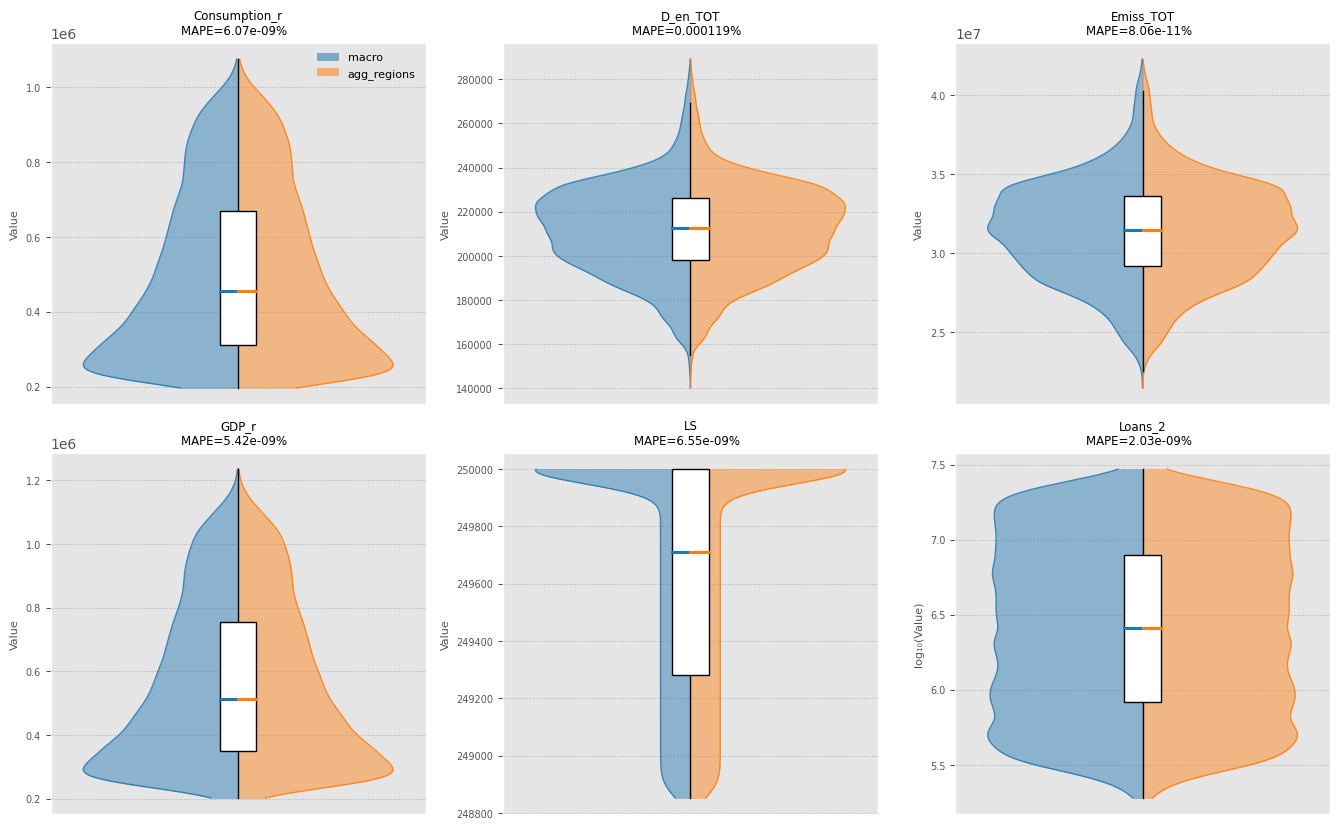

        variable  n_obs     mean_bias       mae      rmse  mean_abs_pct_err  \
0  Consumption_r  30000  7.687183e-08  0.000025  0.000029      6.065613e-09   
1       D_en_TOT  30000  3.586138e-04  0.249134  0.287700      1.186877e-04   
2      Emiss_TOT  30000 -4.900768e-08  0.000025  0.000029      8.061886e-11   
3          GDP_r  30000 -9.454132e-08  0.000025  0.000029      5.416708e-09   
4             LS  30000 -1.011100e-06  0.000016  0.000023      6.550948e-09   
5        Loans_2  30000 -1.526724e-07  0.000025  0.000029      2.032864e-09   

   max_abs_pct_err  corr  welch_t_pvalue  cohens_d     ks_pvalue  close_ratio  \
0     2.522111e-08   1.0        1.000000  0.002663  1.000000e+00          1.0   
1     3.244667e-04   1.0        0.999998  0.001246  1.000000e+00          1.0   
2     2.172278e-10   1.0        1.000000 -0.001696  1.000000e+00          1.0   
3     2.377889e-08   1.0        1.000000 -0.003266  1.000000e+00          1.0   
4     2.002168e-08   1.0        1.000000 

In [100]:


check_regional_consistency(
    scenario_results['hrhs_1'],
    group_keys=("scenario", "run", "t"),
    macro_label="macro",
    alpha=0.05,
    rel_tol=0.01,
    abs_tol=1e-3,
    cols={'aggregate': ['GDP_r', 
    'LS', 
    'Emiss_TOT',
    'Consumption_r',
    'Loans_2', 'D_en_TOT'],
    },
    output = f"../figures/verification/regional_consistency_NoShock.pdf"
)

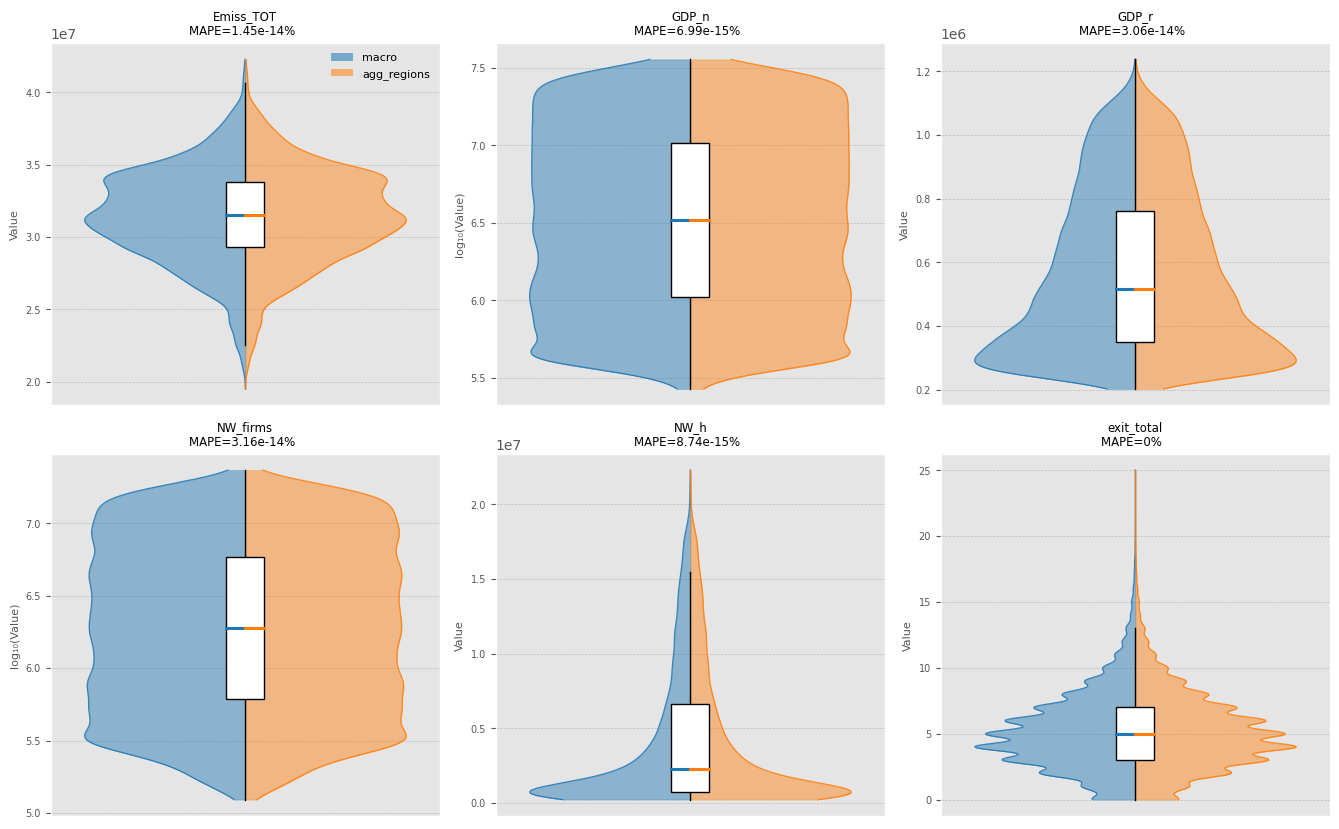

     variable  n_obs     mean_bias           mae          rmse  \
0   Emiss_TOT  30000  4.374733e-10  4.529332e-09  6.192168e-09   
1       GDP_n  30000  1.113105e-10  4.233152e-10  1.067470e-09   
2       GDP_r  30000 -1.166093e-12  1.685209e-10  2.307337e-10   
3    NW_firms  30000  6.792058e-11  1.212985e-09  2.355792e-09   
4        NW_h  30000  6.241996e-11  3.234522e-10  7.420425e-10   
5  exit_total  30000  0.000000e+00  0.000000e+00  0.000000e+00   

   mean_abs_pct_err  max_abs_pct_err  corr  welch_t_pvalue  cohens_d  \
0      1.446121e-14     1.910619e-13   1.0             1.0  0.070825   
1      6.992415e-15     7.384481e-14   1.0             1.0  0.104845   
2      3.063630e-14     3.933948e-13   1.0             1.0 -0.005054   
3      3.156731e-14     1.741222e-13   1.0             1.0  0.028843   
4      8.741797e-15     8.851141e-14   1.0             1.0  0.084417   
5      0.000000e+00     0.000000e+00   1.0             1.0  0.000000   

   ks_pvalue  close_ratio  passe

In [101]:
check_regional_consistency(
    scenario_results['hrhs_2'],
    group_keys=("scenario", "run", "t"),
    macro_label="macro",
    alpha=0.05,
    rel_tol=0.01,
    abs_tol=1e-3,
    cols={'aggregate': ['GDP_r', 
    'exit_total', 'GDP_n',
    'Emiss_TOT', 'NW_firms', 'NW_h']},
    output = f"../figures/verification/regional_consistency_CS.pdf"
)

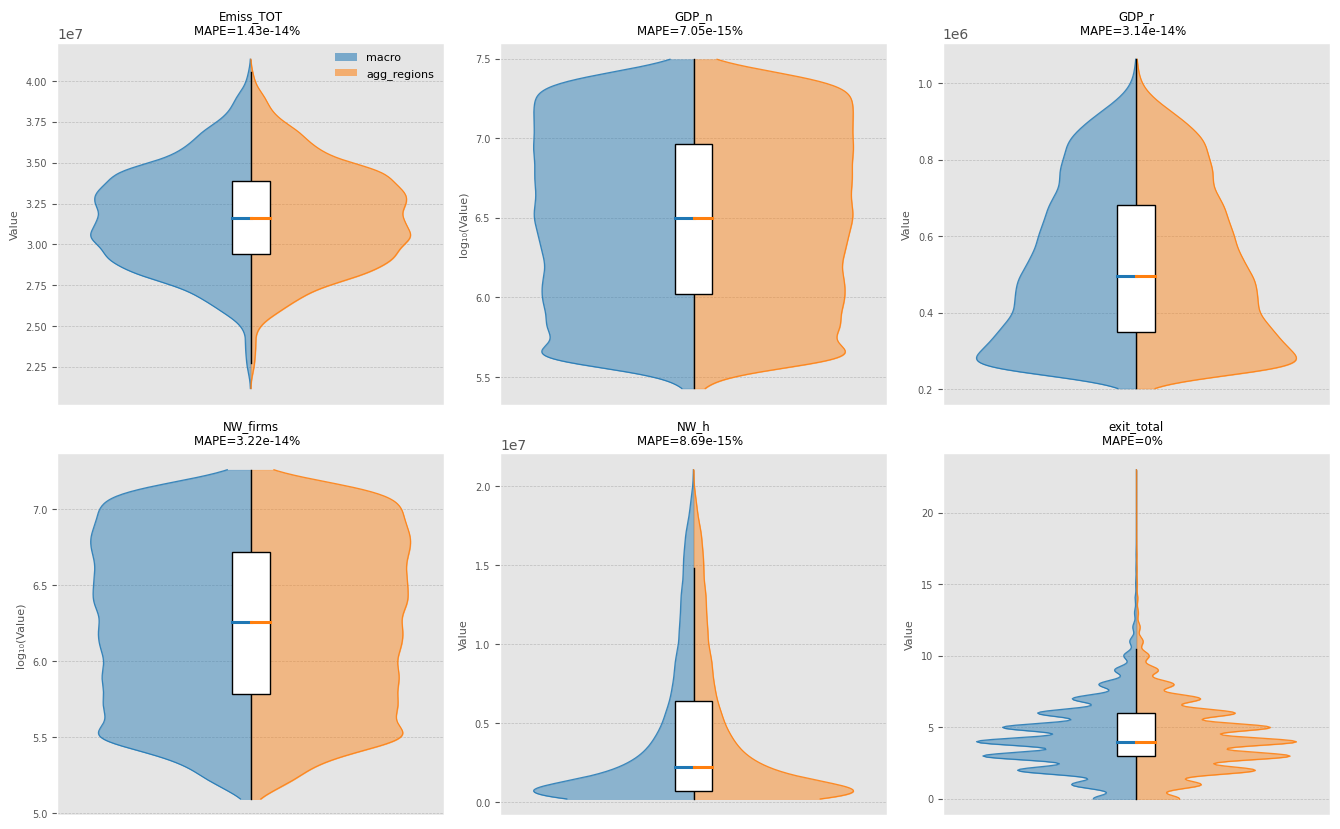

     variable  n_obs     mean_bias           mae          rmse  \
0   Emiss_TOT  30000  3.604839e-10  4.506732e-09  6.183421e-09   
1       GDP_n  30000  8.646554e-11  3.765492e-10  9.521859e-10   
2       GDP_r  30000 -4.374306e-12  1.620414e-10  2.201816e-10   
3    NW_firms  30000  4.837008e-11  1.118827e-09  2.099164e-09   
4        NW_h  30000  6.194168e-11  3.195785e-10  7.420840e-10   
5  exit_total  30000  0.000000e+00  0.000000e+00  0.000000e+00   

   mean_abs_pct_err  max_abs_pct_err  corr  welch_t_pvalue  cohens_d  \
0      1.425858e-14     1.910619e-13   1.0             1.0  0.058397   
1      7.047622e-15     7.384481e-14   1.0             1.0  0.091183   
2      3.140853e-14     3.933948e-13   1.0             1.0 -0.019870   
3      3.217057e-14     1.741222e-13   1.0             1.0  0.023048   
4      8.686856e-15     8.851141e-14   1.0             1.0  0.083761   
5      0.000000e+00     0.000000e+00   1.0             1.0  0.000000   

   ks_pvalue  close_ratio  passe

In [102]:
check_regional_consistency(
    scenario_results['hrhs_3'],
    group_keys=("scenario", "run", "t"),
    macro_label="macro",
    alpha=0.05,
    rel_tol=0.01,
    abs_tol=1e-3,
    cols={'aggregate': ['GDP_r', 
    'exit_total', 'GDP_n',
    'Emiss_TOT', 'NW_firms', 'NW_h']},
    output = f"../figures/verification/regional_consistency_LPEF.pdf"
)